# Reuters News Topic Classification - Exploratory Data Analysis

This notebook performs detailed exploratory data analysis on the Reuters news topic classification dataset. We'll analyze various aspects of the data to better understand its characteristics and potential challenges.

## Setup and Data Loading

In [2]:
import logging
import warnings
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from src.dataset import load_data
from src.exploration import class_frequency, length_distribution

# Disable HuggingFace tokenizers parallelism
os.environ["TOKENIZERS_PARALLELISM"] = "false"

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
SEED = 42
random.seed(SEED)

# Load dataset
N_CLASSES = 10
X_train, y_train, X_test, y_test, label_names = load_data(N_CLASSES)
print(f'Train docs: {len(X_train):,},  Test docs: {len(X_test):,}')
print('Labels:', label_names)

Train docs: 6,337,  Test docs: 2,477
Labels: ['earn', 'acq', 'crude', 'interest', 'money-fx', 'trade', 'grain', 'corn', 'dlr', 'money-supply']


## 1. Class Distribution Analysis

Let's analyze the distribution of topics in our dataset to understand class imbalance.

<Figure size 1200x600 with 0 Axes>

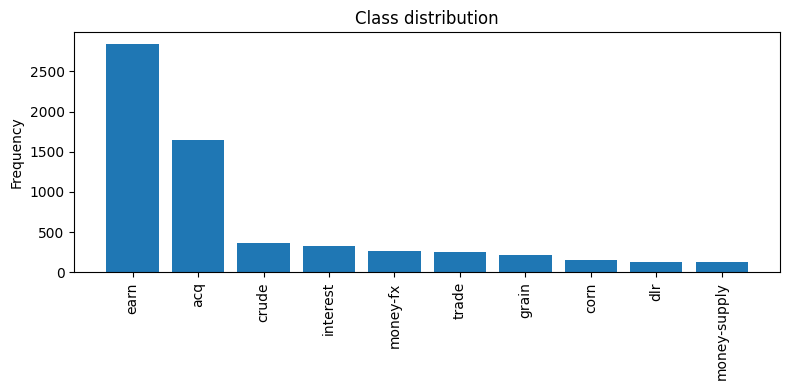


Class Distribution Statistics:
earn: 2,843 documents (44.9%)
acq: 1,650 documents (26.0%)
crude: 370 documents (5.8%)
interest: 329 documents (5.2%)
money-fx: 266 documents (4.2%)
trade: 253 documents (4.0%)
grain: 218 documents (3.4%)
corn: 157 documents (2.5%)
dlr: 126 documents (2.0%)
money-supply: 125 documents (2.0%)


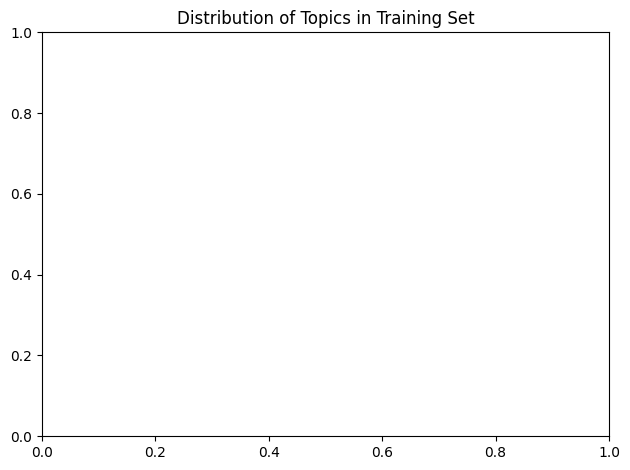

In [3]:
# Plot class distribution
plt.figure(figsize=(12, 6))
class_frequency(y_train, top_n=20)
plt.title('Distribution of Topics in Training Set')
plt.tight_layout()

# Calculate class imbalance statistics
class_counts = Counter(y_train)
total = len(y_train)
print("\nClass Distribution Statistics:")
for label in label_names:
    count = class_counts[label]
    percentage = (count / total) * 100
    print(f"{label}: {count:,} documents ({percentage:.1f}%)")

## 2. Document Length Analysis

Understanding the length distribution of articles helps us make decisions about preprocessing and model architecture.

<Figure size 1000x600 with 0 Axes>

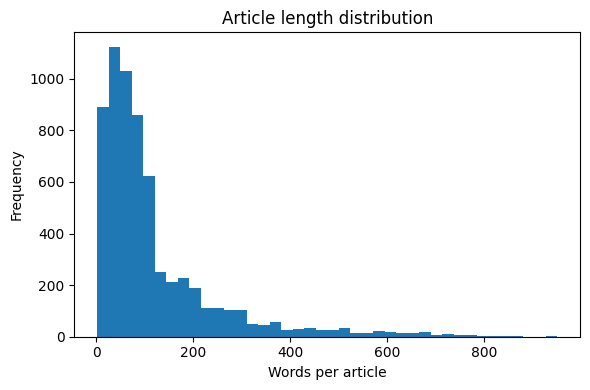

Mean length: 119.9 tokens
Median length: 77.0 tokens

Document Length Percentiles:
25th percentile: 40 tokens
50th percentile: 77 tokens
75th percentile: 142 tokens
90th percentile: 278 tokens
95th percentile: 404 tokens
99th percentile: 667 tokens


In [4]:
# Plot length distribution
plt.figure(figsize=(10, 6))
mean_len, median_len = length_distribution(X_train)
print(f"Mean length: {mean_len:.1f} tokens")
print(f"Median length: {median_len:.1f} tokens")

# Calculate length percentiles
lengths = [len(doc.split()) for doc in X_train]
percentiles = np.percentile(lengths, [25, 50, 75, 90, 95, 99])
print("\nDocument Length Percentiles:")
print(f"25th percentile: {percentiles[0]:.0f} tokens")
print(f"50th percentile: {percentiles[1]:.0f} tokens")
print(f"75th percentile: {percentiles[2]:.0f} tokens")
print(f"90th percentile: {percentiles[3]:.0f} tokens")
print(f"95th percentile: {percentiles[4]:.0f} tokens")
print(f"99th percentile: {percentiles[5]:.0f} tokens")

## 3. Vocabulary Analysis

Let's examine the vocabulary characteristics of our dataset.

In [5]:
from collections import Counter
import re

# Tokenize and count words
def get_vocab_stats(texts):
    words = []
    for doc in texts:
        words.extend(re.findall(r'\w+', doc.lower()))
    word_counts = Counter(words)
    return word_counts

word_counts = get_vocab_stats(X_train)

print(f"Total unique words: {len(word_counts):,}")
print("\nMost common words:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count:,}")

Total unique words: 23,125

Most common words:
the: 36,685
of: 20,560
to: 20,326
in: 15,268
said: 14,093
and: 13,868
a: 13,790
mln: 11,605
vs: 9,234
s: 8,693
dlrs: 7,810
for: 7,568
it: 6,836
lt: 6,003
000: 5,930
cts: 5,702
1: 5,521
on: 4,908
its: 4,709
pct: 4,703


## 4. Topic Co-occurrence Analysis

Let's examine if there are any patterns in how topics appear together in articles.

In [6]:
# Create co-occurrence matrix
def get_topic_cooccurrence(labels):
    unique_labels = sorted(set(labels))
    cooccurrence = np.zeros((len(unique_labels), len(unique_labels)))
    label_to_idx = {label: i for i, label in enumerate(unique_labels)}
    
    for i, label1 in enumerate(unique_labels):
        for j, label2 in enumerate(unique_labels):
            if i <= j:  # Only compute upper triangle
                cooccurrence[i, j] = sum((y_train == label1) & (y_test == label2))
                cooccurrence[j, i] = cooccurrence[i, j]  # Mirror
    
    return pd.DataFrame(cooccurrence, index=unique_labels, columns=unique_labels)

cooccurrence_df = get_topic_cooccurrence(y_train)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence_df, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Topic Co-occurrence Matrix')
plt.tight_layout()

TypeError: 'bool' object is not iterable

## Key Findings

1. **Class Imbalance**: The dataset shows significant class imbalance, with 'earn' and 'acq' being the dominant classes.

2. **Document Length**: Most articles are relatively short, with a median length of around 77 tokens. However, there's a long tail of longer articles.

3. **Vocabulary**: The dataset has a rich vocabulary, with many domain-specific financial terms.

4. **Topic Relationships**: Some topics show stronger co-occurrence patterns than others, which could be useful for multi-label classification.

## Next Steps

Based on this analysis, in the next notebook we'll:
1. Implement appropriate class balancing techniques
2. Design a preprocessing pipeline that handles the document length distribution
3. Create an effective vocabulary management strategy